# SIM 1010s / 1020s / 1030s — Combined, Elastic-Modulus-Normalized Comparison

Combines the three foam-compression families onto the same axes:

| Family | Sims | Elastic modulus `E` (material input) |
|---|---|---|
| 1010s | 1010–1019 | 20 |
| 1020s | 1020–1028 | 10 |
| 1030s | 1030–1038 | 5 |

Each family sweeps the same 10-level internal pressure series:
`P = [0.0] + [0.004 × √2^i for i in 0..8]`.

**Normalization.** Reaction force `RF2` is the only plotted quantity carrying
force/stress units, so it is normalized as `RF2 / E` to make the families
directly comparable (removing the trivial stiffness scaling). The other
quantities reproduced from the SIM 1030s notebook — factor `f`
(tension/compression efficiency ratio), `shear_mean` (a purely kinematic,
deformation-gradient-based measure), and the localization indices `η_A`,
`η_C` (geometric, area/aspect-ratio based) — are dimensionless and are
**not** functions of the material elastic modulus, so they are plotted as-is
(only combined across families, not rescaled).

**Plots** (same set as SIM 1030s analysis, now overlaid for all 3 families)
1. Reaction force / E vs displacement — all sims, all families
2. Factor `f` vs displacement — all sims, all families
3. Shear mean vs displacement — all sims, all families
4. η_A (area-based) and η_C (aspect-ratio-based) localization indices vs displacement — all sims, all families


In [1]:
import sys, os, pickle, json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

sys.path.insert(0, os.path.abspath('..'))

RESULTS_DIR = '../I001_Results'
OBJ_DIR     = '../I001_Results/OBJ_files'

# Family definitions: sim id list, elastic modulus E (material input, see
# D001_Input_files_creator/SIM_1010_inp_creator.py, SIM_1020_inp_creator.py,
# SIM_1030_inp_creator.py), a short label, and a colormap used to shade the
# individual pressure levels within the family.
FAMILIES = {
    '1010s': {'sims': list(range(1010, 1020)),           'E': 20, 'cmap': 'Blues'},
    '1020s': {'sims': list(range(1020, 1029)),           'E': 10, 'cmap': 'Oranges'},
    '1030s': {'sims': list(range(1030, 1039)),           'E': 5,  'cmap': 'Greens'},
}
FAM_NAMES = list(FAMILIES.keys())


In [2]:
def load_pkl(path):
    if not os.path.exists(path):
        return None
    with open(path, 'rb') as f:
        return pickle.load(f)

def get_pressure(sim):
    path = os.path.join(OBJ_DIR, f'SIM_{sim:03d}.json')
    if not os.path.exists(path):
        return None
    with open(path) as f:
        d = json.load(f)
    for step in d.get('steps', []):
        pb = step.get('Pressure_BC', 0)
        if pb:
            return float(pb)
    return 0.0


In [3]:
PRESSURES = {}
for fam, info in FAMILIES.items():
    for sim in info['sims']:
        PRESSURES[sim] = get_pressure(sim)

for fam, info in FAMILIES.items():
    print(fam, 'E =', info['E'], {sim: f'{PRESSURES[sim]:.4g} MPa' for sim in info['sims']})


1010s E = 20 {1010: '0 MPa', 1011: '0.04 MPa', 1012: '0.05657 MPa', 1013: '0.08 MPa', 1014: '0.1131 MPa', 1015: '0.16 MPa', 1016: '0.2263 MPa', 1017: '0.32 MPa', 1018: '0.4525 MPa', 1019: '0.64 MPa'}
1020s E = 10 {1020: '0 MPa', 1021: '0.04 MPa', 1022: '0.05657 MPa', 1023: '0.08 MPa', 1024: '0.1131 MPa', 1025: '0.16 MPa', 1026: '0.2263 MPa', 1027: '0.32 MPa', 1028: '0.4525 MPa'}
1030s E = 5 {1030: '0 MPa', 1031: '0.04 MPa', 1032: '0.05657 MPa', 1033: '0.08 MPa', 1034: '0.1131 MPa', 1035: '0.16 MPa', 1036: '0.2263 MPa', 1037: '0.32 MPa', 1038: '0.4525 MPa'}


## Localization points

LocalizationA = displacement at the minimum of `shear_mean`, computed
per-sim exactly as in the SIM 1020s / SIM 1030s notebooks (LocalizationB is
on standby / not used, consistent with those notebooks).

In [4]:
def mark_localizations(ax, color, sim, displ, y):
    if sim in LOC_A:
        xA = LOC_A[sim]
        yA = np.interp(xA, displ, y)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=color, linewidths=1.8, zorder=5)
    if sim in LOC_B:
        xB = LOC_B[sim]
        yB = np.interp(xB, displ, y)
        ax.scatter(xB, yB, marker='^', s=70, facecolor=color,
                   edgecolor='k', linewidths=0.8, zorder=5)

def add_localization_legend(ax):
    handles, labels = ax.get_legend_handles_labels()
    if LOC_A:
        handles.append(Line2D([], [], marker='v', linestyle='None', markerfacecolor='none', markeredgecolor='k', markersize=8))
        labels.append('Localization A')
    if LOC_B:
        handles.append(Line2D([], [], marker='^', linestyle='None', markerfacecolor='k', markeredgecolor='k', markersize=8))
        labels.append('Localization B')
    return handles, labels

def family_color(fam, idx, n):
    cmap = plt.get_cmap(FAMILIES[fam]['cmap'], max(n, 2))
    # skip the very lightest shade so low-pressure curves stay visible
    return cmap(idx + 1) if cmap.N > n else cmap(idx)

def fam_legend_handles():
    handles = []
    for fam, info in FAMILIES.items():
        cmap = plt.get_cmap(info['cmap'])
        handles.append(Line2D([], [], color=cmap(0.7), lw=2, label=f"{fam} (E={info['E']})"))
    return handles


In [5]:
LOC_A = {}
LOC_B = {}

for fam, info in FAMILIES.items():
    for sim in info['sims']:
        a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
        tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
        if a2 is None or tp2l is None:
            del a2, tp2l
            continue
        displ      = -np.array(a2['U2']['PERN-9999997'])
        shear_mean = np.array(tp2l['shear_mean'])
        del a2, tp2l

        idx_min = np.argmin(shear_mean)
        LOC_A[sim] = displ[idx_min]

LOC_A


{1010: 2.450000047683716,
 1011: 2.7649455070495605,
 1012: 2.869150161743164,
 1013: 3.0453219413757324,
 1014: 3.2962982654571533,
 1015: 3.6289710998535156,
 1016: 4.058625221252441,
 1017: 4.619215965270996,
 1018: 5.0,
 1020: 2.575000047683716,
 1021: 3.151005983352661,
 1022: 3.3774607181549072,
 1023: 3.656994342803955,
 1024: 4.029257297515869,
 1025: 4.5240631103515625,
 1026: 5.0,
 1030: 2.700000047683716,
 1031: 3.6291027069091797,
 1032: 3.911703586578369,
 1033: 4.302085876464844,
 1034: 4.856770038604736}

## Plot 1 — Reaction force / E vs displacement — all families

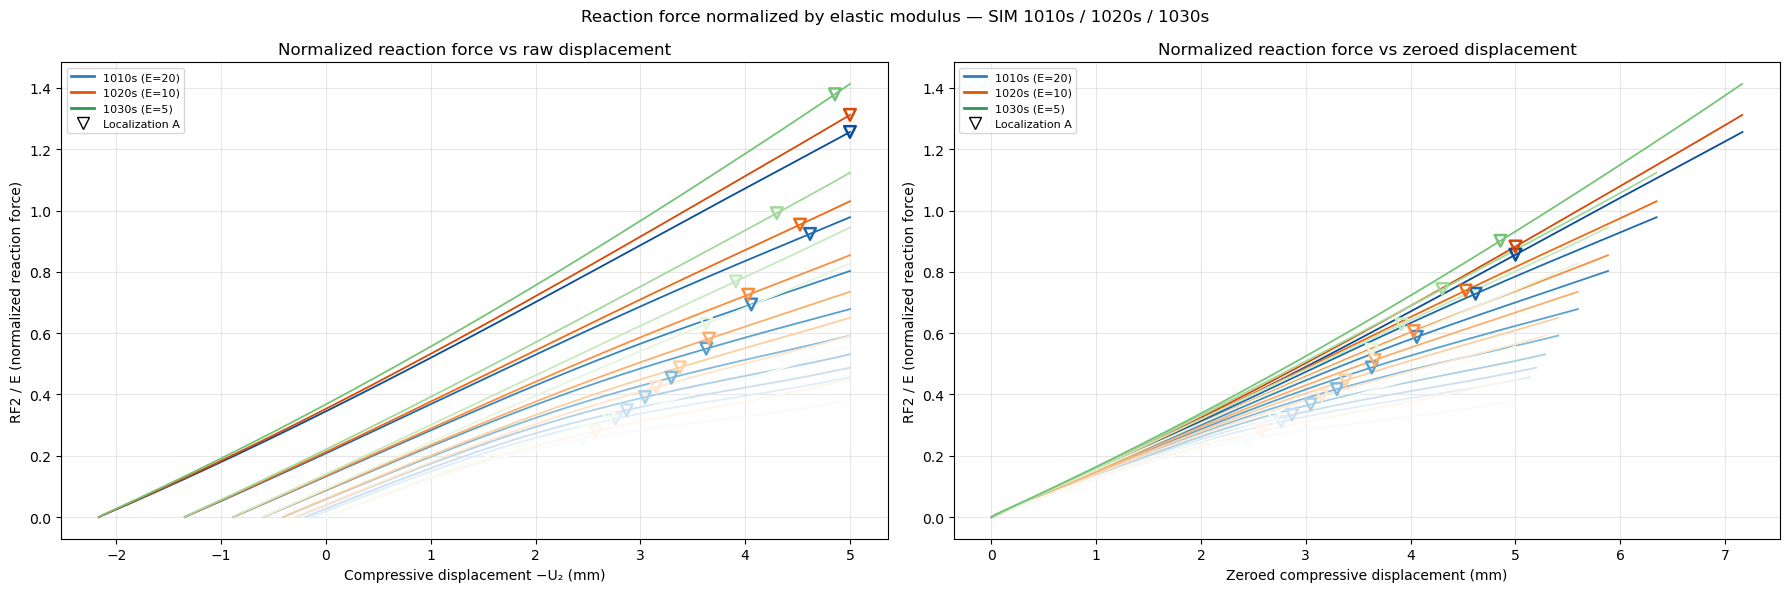

In [6]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(18, 6))

for fam, info in FAMILIES.items():
    sims, E = info['sims'], info['E']
    for idx, sim in enumerate(sims):
        a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
        if a2 is None:
            continue
        # U2 at PERN-9999997 is signed (positive = pressure-induced expansion in
        # Step-0, ramping down through 0 to the imposed compression in Step-1) and
        # is monotonically decreasing over time. Negate (don't abs!) to get a
        # monotonically increasing compressive-displacement axis.
        displ  = -np.array(a2['U2']['PERN-9999997'])
        rf2    = np.abs(np.array(a2['RF2']['PERN-9999997']))
        rf2_En = rf2 / E   # normalized by the family's elastic modulus
        del a2

        color = family_color(fam, idx, len(sims))
        ax.plot(displ, rf2_En, color=color, lw=1.3)
        mark_localizations(ax, color, sim, displ, rf2_En)

        # Zeroed displacement: subtract displ(t=0) so every sim starts at 0,
        # removing the pressure-induced Step-0 expansion offset.
        displ0     = displ[0]
        displ_zero = displ - displ0
        ax2.plot(displ_zero, rf2_En, color=color, lw=1.3)
        mark_localizations(ax2, color, sim, displ_zero, rf2_En)

ax.set_xlabel('Compressive displacement −U₂ (mm)')
ax.set_ylabel('RF2 / E (normalized reaction force)')
ax.set_title('Normalized reaction force vs raw displacement')
h, l = add_localization_legend(ax)
ax.legend(fam_legend_handles() + h, [hh.get_label() for hh in fam_legend_handles()] + l, loc='best', fontsize=8)
ax.grid(True, alpha=0.3)

ax2.set_xlabel('Zeroed compressive displacement (mm)')
ax2.set_ylabel('RF2 / E (normalized reaction force)')
ax2.set_title('Normalized reaction force vs zeroed displacement')
h2, l2 = add_localization_legend(ax2)
ax2.legend(fam_legend_handles() + h2, [hh.get_label() for hh in fam_legend_handles()] + l2, loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

fig.suptitle('Reaction force normalized by elastic modulus — SIM 1010s / 1020s / 1030s')
fig.tight_layout()
plt.show()


## Plot 1s — Reaction force / E vs strain (from t=0) — all families

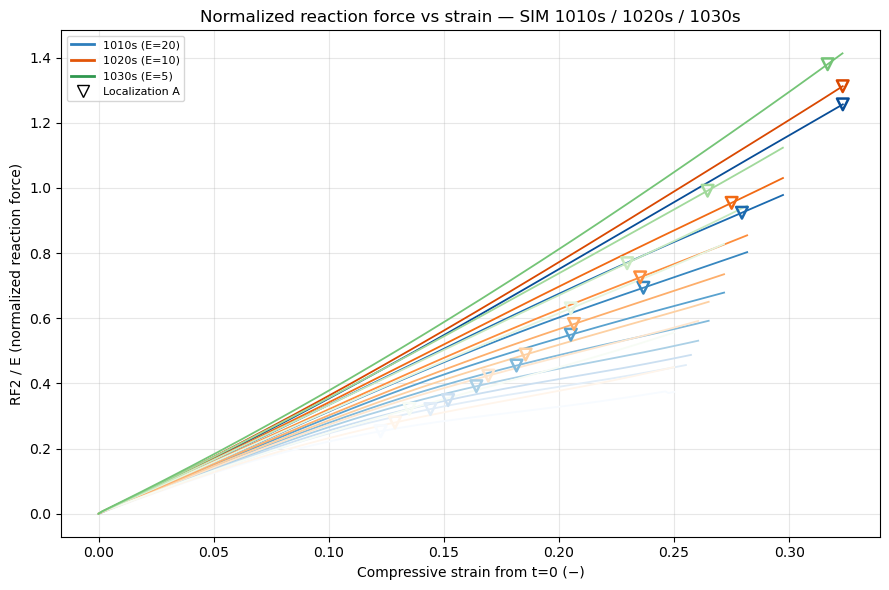

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))

for fam, info in FAMILIES.items():
    sims, E = info['sims'], info['E']
    for idx, sim in enumerate(sims):
        a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
        if a2 is None:
            continue
        displ  = -np.array(a2['U2']['PERN-9999997'])
        rf2    = np.abs(np.array(a2['RF2']['PERN-9999997']))
        rf2_En = rf2 / E
        del a2

        # Compressive displacement from t=0, and the corresponding strain.
        # Original height at the start of Step-1 (post pressure-expansion,
        # pre-loading) = 20 - displ(t=0), since displ(t=0) is negative/zero.
        displ0     = displ[0]
        displ_zero = displ - displ0
        height0    = 20 - displ0
        strain     = displ_zero / height0

        color = family_color(fam, idx, len(sims))
        ax.plot(strain, rf2_En, color=color, lw=1.3)
        if sim in LOC_A:
            xA = (LOC_A[sim] - displ0) / height0
            yA = np.interp(xA, strain, rf2_En)
            ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                       edgecolor=color, linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive strain from t=0 (−)')
ax.set_ylabel('RF2 / E (normalized reaction force)')
ax.set_title('Normalized reaction force vs strain — SIM 1010s / 1020s / 1030s')
h, l = add_localization_legend(ax)
ax.legend(fam_legend_handles() + h, [hh.get_label() for hh in fam_legend_handles()] + l, loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 2 — Factor `f` (tension / compression efficiency) vs displacement — all families

`f` is a dimensionless ratio of network efficiencies and does not depend on
the material elastic modulus, so it is combined across families unscaled.

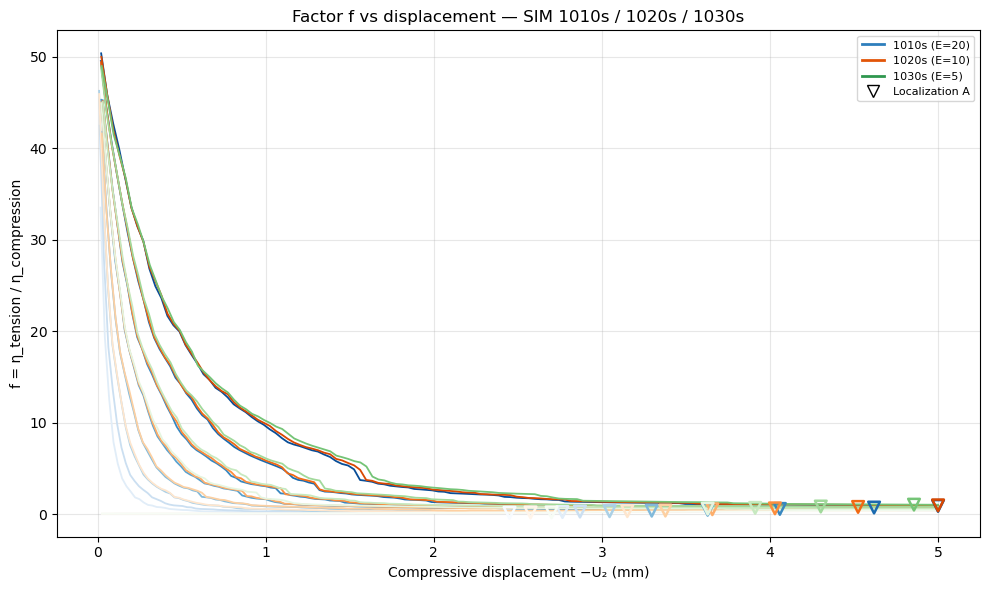

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

for fam, info in FAMILIES.items():
    sims = info['sims']
    for idx, sim in enumerate(sims):
        a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
        i3 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I3_BFS_3002.pkl'))
        if a2 is None or i3 is None:
            del a2, i3
            continue
        displ = -np.array(a2['U2']['PERN-9999997'])
        ef_t  = np.array(i3['global_ef_t'], dtype=float)
        ef_c  = np.array(i3['global_ef_c'], dtype=float)
        del a2, i3

        with np.errstate(divide='ignore', invalid='ignore'):
            f = np.where(ef_c != 0, ef_t / ef_c, np.nan)
        del ef_t, ef_c

        mask  = ~np.isnan(f) & (displ > 0)
        color = family_color(fam, idx, len(sims))
        ax.plot(displ[mask], f[mask], color=color, lw=1.3)
        mark_localizations(ax, color, sim, displ, f)

ax.set_xlabel('Compressive displacement −U₂ (mm)')
ax.set_ylabel('f = η_tension / η_compression')
ax.set_title('Factor f vs displacement — SIM 1010s / 1020s / 1030s')
h, l = add_localization_legend(ax)
ax.legend(fam_legend_handles() + h, [hh.get_label() for hh in fam_legend_handles()] + l, loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 2s — Factor `f` vs strain (from t=0) — all families

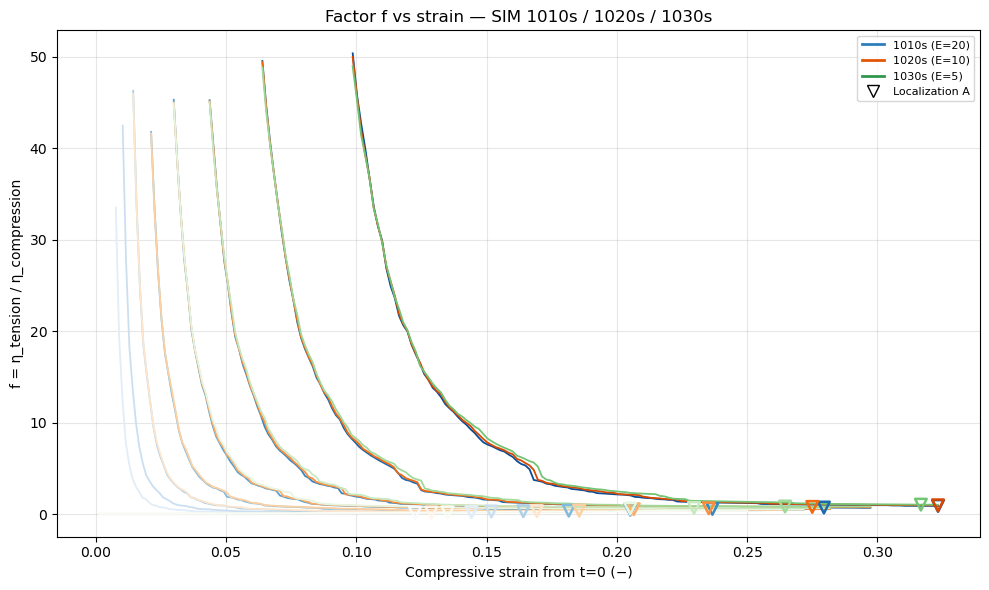

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

for fam, info in FAMILIES.items():
    sims = info['sims']
    for idx, sim in enumerate(sims):
        a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
        i3 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I3_BFS_3002.pkl'))
        if a2 is None or i3 is None:
            del a2, i3
            continue
        displ = -np.array(a2['U2']['PERN-9999997'])
        ef_t  = np.array(i3['global_ef_t'], dtype=float)
        ef_c  = np.array(i3['global_ef_c'], dtype=float)
        del a2, i3

        with np.errstate(divide='ignore', invalid='ignore'):
            f = np.where(ef_c != 0, ef_t / ef_c, np.nan)
        del ef_t, ef_c

        displ0     = displ[0]
        displ_zero = displ - displ0
        height0    = 20 - displ0
        strain     = displ_zero / height0

        mask  = ~np.isnan(f) & (displ > 0)
        color = family_color(fam, idx, len(sims))
        ax.plot(strain[mask], f[mask], color=color, lw=1.3)
        if sim in LOC_A:
            xA = (LOC_A[sim] - displ0) / height0
            yA = np.interp(xA, strain, f)
            ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                       edgecolor=color, linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive strain from t=0 (−)')
ax.set_ylabel('f = η_tension / η_compression')
ax.set_title('Factor f vs strain — SIM 1010s / 1020s / 1030s')
h, l = add_localization_legend(ax)
ax.legend(fam_legend_handles() + h, [hh.get_label() for hh in fam_legend_handles()] + l, loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 3 — Shear mean vs displacement — all families

`shear_mean` is a purely kinematic (deformation-gradient-based) quantity and
does not depend on the material elastic modulus, so it is combined across
families unscaled.

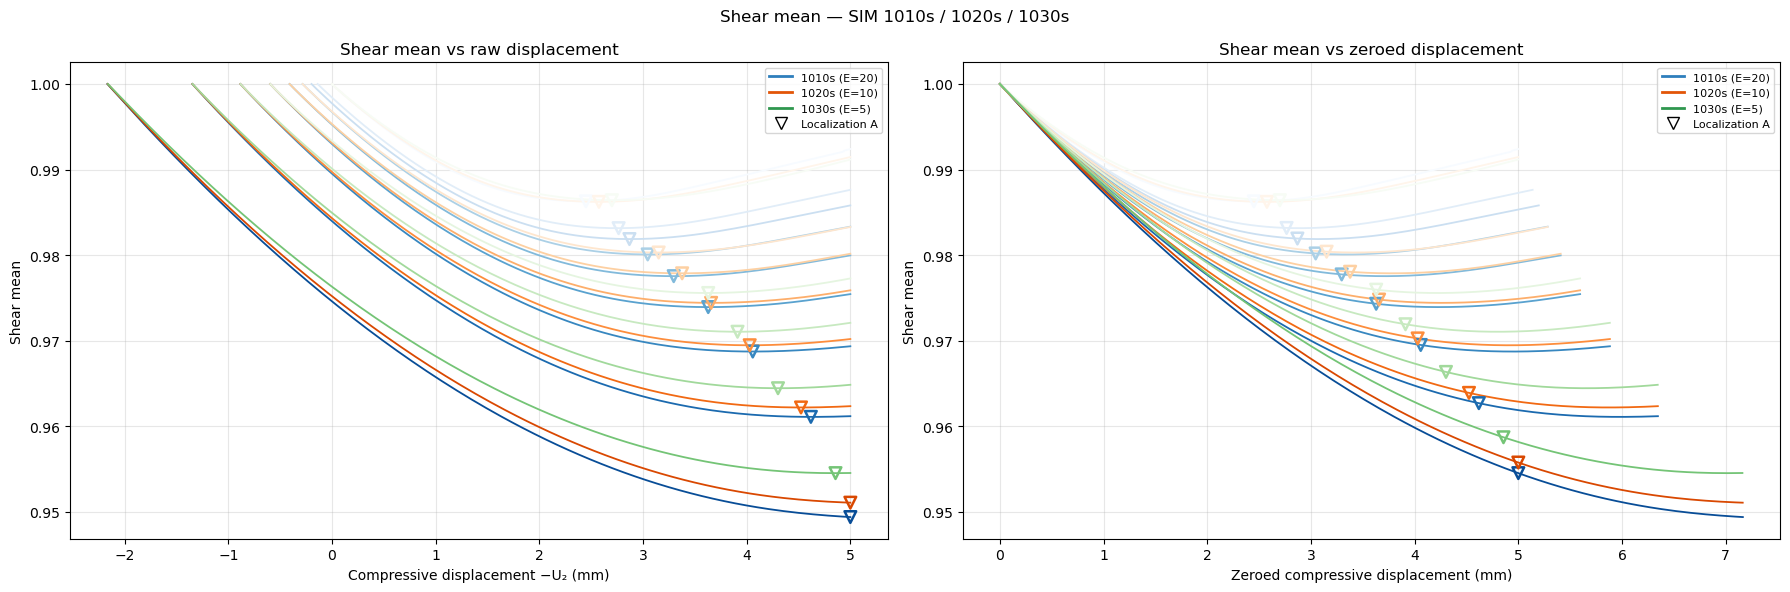

In [10]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(18, 6))

for fam, info in FAMILIES.items():
    sims = info['sims']
    for idx, sim in enumerate(sims):
        a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
        tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
        if a2 is None or tp2l is None:
            del a2, tp2l
            continue
        displ      = -np.array(a2['U2']['PERN-9999997'])
        shear_mean = np.array(tp2l['shear_mean'])
        del a2, tp2l

        color = family_color(fam, idx, len(sims))
        ax.plot(displ, shear_mean, color=color, lw=1.3)
        mark_localizations(ax, color, sim, displ, shear_mean)

        displ0     = displ[0]
        displ_zero = displ - displ0
        ax2.plot(displ_zero, shear_mean, color=color, lw=1.3)
        mark_localizations(ax2, color, sim, displ_zero, shear_mean)

ax.set_xlabel('Compressive displacement −U₂ (mm)')
ax.set_ylabel('Shear mean')
ax.set_title('Shear mean vs raw displacement')
h, l = add_localization_legend(ax)
ax.legend(fam_legend_handles() + h, [hh.get_label() for hh in fam_legend_handles()] + l, loc='best', fontsize=8)
ax.grid(True, alpha=0.3)

ax2.set_xlabel('Zeroed compressive displacement (mm)')
ax2.set_ylabel('Shear mean')
ax2.set_title('Shear mean vs zeroed displacement')
h2, l2 = add_localization_legend(ax2)
ax2.legend(fam_legend_handles() + h2, [hh.get_label() for hh in fam_legend_handles()] + l2, loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

fig.suptitle('Shear mean — SIM 1010s / 1020s / 1030s')
fig.tight_layout()
plt.show()


## Plot 3s — Shear mean vs strain (from t=0) — all families

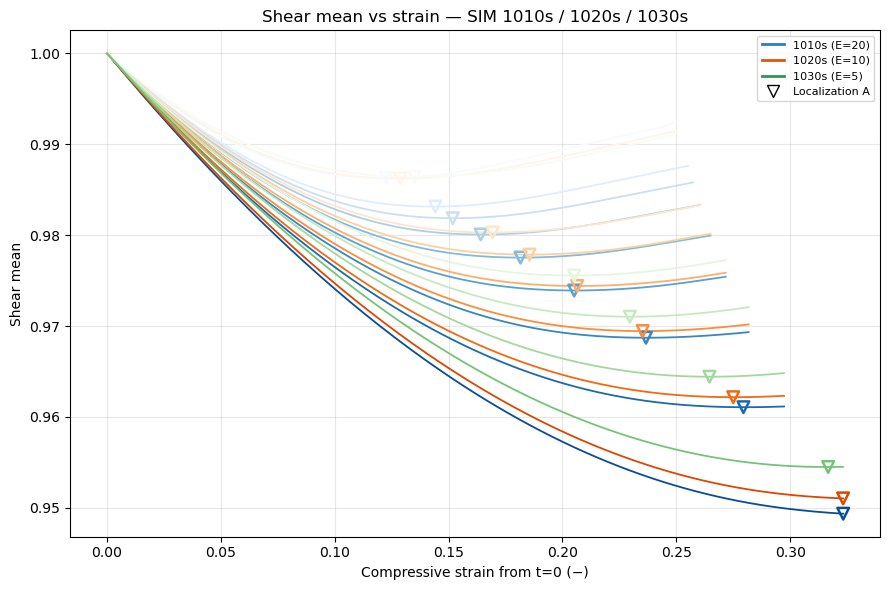

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))

for fam, info in FAMILIES.items():
    sims = info['sims']
    for idx, sim in enumerate(sims):
        a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
        tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
        if a2 is None or tp2l is None:
            del a2, tp2l
            continue
        displ      = -np.array(a2['U2']['PERN-9999997'])
        shear_mean = np.array(tp2l['shear_mean'])
        del a2, tp2l

        displ0     = displ[0]
        displ_zero = displ - displ0
        height0    = 20 - displ0
        strain     = displ_zero / height0

        color = family_color(fam, idx, len(sims))
        ax.plot(strain, shear_mean, color=color, lw=1.3)
        if sim in LOC_A:
            xA = (LOC_A[sim] - displ0) / height0
            yA = np.interp(xA, strain, shear_mean)
            ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                       edgecolor=color, linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive strain from t=0 (−)')
ax.set_ylabel('Shear mean')
ax.set_title('Shear mean vs strain — SIM 1010s / 1020s / 1030s')
h, l = add_localization_legend(ax)
ax.legend(fam_legend_handles() + h, [hh.get_label() for hh in fam_legend_handles()] + l, loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 3b — d(Shear mean)/d(displacement) vs displacement — all families

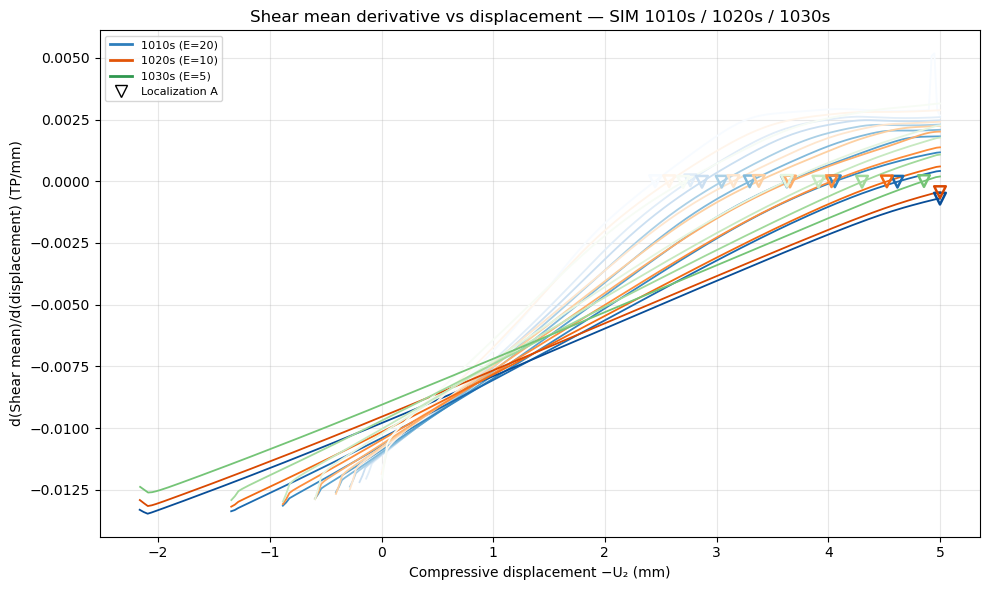

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

for fam, info in FAMILIES.items():
    sims = info['sims']
    for idx, sim in enumerate(sims):
        a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
        tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
        if a2 is None or tp2l is None:
            del a2, tp2l
            continue
        displ      = -np.array(a2['U2']['PERN-9999997'])
        shear_mean = np.array(tp2l['shear_mean'])
        del a2, tp2l

        dshear_dd = np.gradient(shear_mean, displ)
        color = family_color(fam, idx, len(sims))
        ax.plot(displ, dshear_dd, color=color, lw=1.3)
        mark_localizations(ax, color, sim, displ, dshear_dd)

ax.set_xlabel('Compressive displacement −U₂ (mm)')
ax.set_ylabel('d(Shear mean)/d(displacement) (TP/mm)')
ax.set_title('Shear mean derivative vs displacement — SIM 1010s / 1020s / 1030s')
h, l = add_localization_legend(ax)
ax.legend(fam_legend_handles() + h, [hh.get_label() for hh in fam_legend_handles()] + l, loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 4 — $\eta_A$ (area-based) and $\eta_C$ (aspect-ratio-based) localization indices vs displacement — all families

Both indices are dimensionless geometric measures independent of the
material elastic modulus, so they are combined across families unscaled.

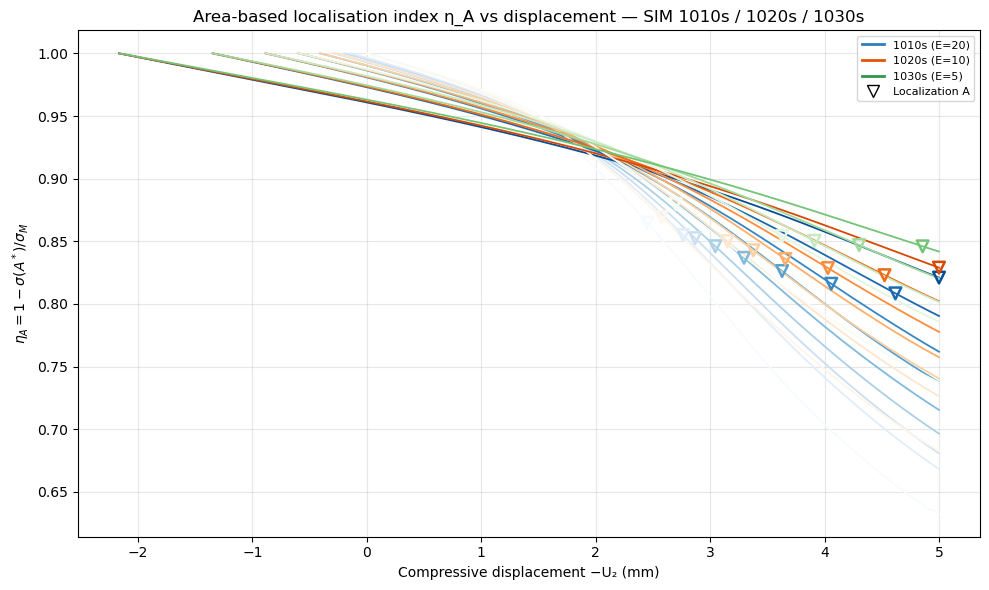

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

for fam, info in FAMILIES.items():
    sims = info['sims']
    for idx, sim in enumerate(sims):
        defc2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_DEFC2.pkl'))
        if defc2 is None:
            continue
        # displacement here matches A2's U2 sign convention (signed, decreasing).
        displ  = -np.array(defc2['displacement'])
        eta_a  = np.array(defc2['etaC_A'])
        del defc2

        color = family_color(fam, idx, len(sims))
        ax.plot(displ, eta_a, color=color, lw=1.3)
        mark_localizations(ax, color, sim, displ, eta_a)

ax.set_xlabel('Compressive displacement −U₂ (mm)')
ax.set_ylabel(r'$\eta_A = 1 - \sigma(A^*)/\sigma_M$')
ax.set_title('Area-based localisation index η_A vs displacement — SIM 1010s / 1020s / 1030s')
h, l = add_localization_legend(ax)
ax.legend(fam_legend_handles() + h, [hh.get_label() for hh in fam_legend_handles()] + l, loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


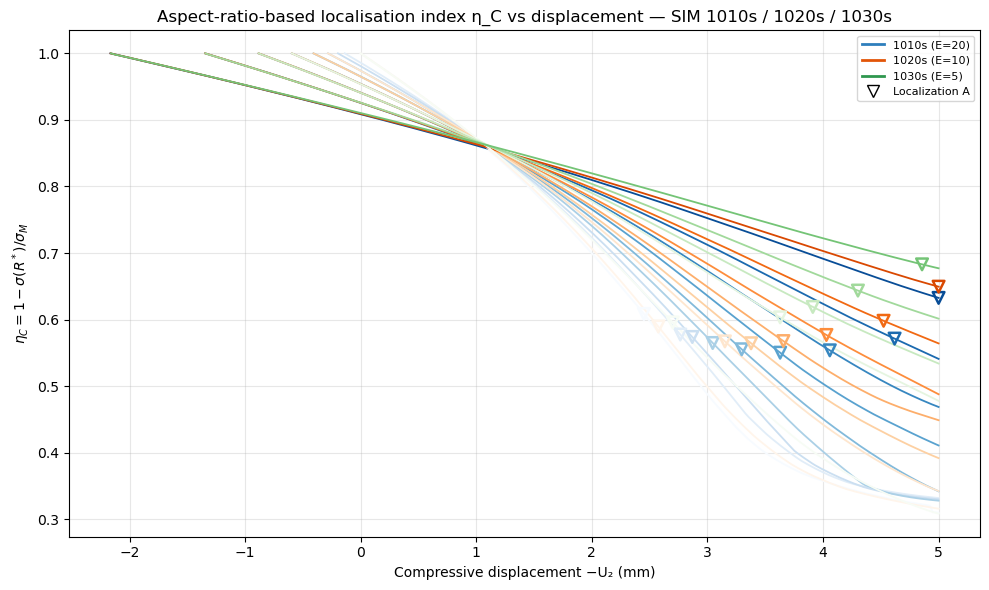

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

for fam, info in FAMILIES.items():
    sims = info['sims']
    for idx, sim in enumerate(sims):
        defc2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_DEFC2.pkl'))
        if defc2 is None:
            continue
        displ  = -np.array(defc2['displacement'])
        eta_c  = np.array(defc2['etaC_R'])
        del defc2

        color = family_color(fam, idx, len(sims))
        ax.plot(displ, eta_c, color=color, lw=1.3)
        mark_localizations(ax, color, sim, displ, eta_c)

ax.set_xlabel('Compressive displacement −U₂ (mm)')
ax.set_ylabel(r'$\eta_C = 1 - \sigma(R^*)/\sigma_M$')
ax.set_title('Aspect-ratio-based localisation index η_C vs displacement — SIM 1010s / 1020s / 1030s')
h, l = add_localization_legend(ax)
ax.legend(fam_legend_handles() + h, [hh.get_label() for hh in fam_legend_handles()] + l, loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 5 — Localization-point summary vs internal pressure — all families

`LocalizationA` displacement/strain/f values are interpolated per sim, then
grouped by family, exactly as in the individual SIM 1010s/1020s/1030s
notebooks. Both quantities below (absolute displacement, factor `f`) are
independent of the elastic modulus, so families are combined unscaled and
distinguished by color/marker.

In [15]:
loc_data = []
for fam, info in FAMILIES.items():
    sims, E = info['sims'], info['E']
    for sim in sims:
        a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
        i3 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I3_BFS_3002.pkl'))
        if a2 is None or i3 is None or sim not in PRESSURES:
            del a2, i3
            continue
        displ = -np.array(a2['U2']['PERN-9999997'])
        ef_t  = np.array(i3['global_ef_t'], dtype=float)
        ef_c  = np.array(i3['global_ef_c'], dtype=float)
        del a2, i3

        with np.errstate(divide='ignore', invalid='ignore'):
            f = np.where(ef_c != 0, ef_t / ef_c, np.nan)
        del ef_t, ef_c

        mask = ~np.isnan(f) & (displ > 0)
        displ_m, f_m = displ[mask], f[mask]

        # displ[0] is the displacement at t=0 (start of the simulation, before
        # the Step-0 pressure ramp), which is nonzero/negative in this signed
        # convention. Subtracting it gives the absolute compressive
        # displacement measured from the true start of the simulation.
        displ0  = displ[0]
        height0 = 20 - displ0  # original height at the start of Step-1

        dispA = LOC_A.get(sim, np.nan)
        dispB = LOC_B.get(sim, np.nan)
        fA = np.interp(dispA, displ_m, f_m) if sim in LOC_A else np.nan
        fB = np.interp(dispB, displ_m, f_m) if sim in LOC_B else np.nan

        dispA_abs = dispA - displ0
        dispB_abs = dispB - displ0

        loc_data.append(dict(fam=fam, sim=sim, E=E, P=PRESSURES[sim],
                              displ0=displ0, height0=height0,
                              dispA=dispA, dispA_abs=dispA_abs, strainA=dispA_abs / height0, fA=fA,
                              dispB=dispB, dispB_abs=dispB_abs, strainB=dispB_abs / height0, fB=fB))

loc_data.sort(key=lambda d: (d['fam'], d['P']))
loc_data


[{'fam': '1010s',
  'sim': 1010,
  'E': 20,
  'P': 0.0,
  'displ0': -0.0,
  'height0': 20.0,
  'dispA': 2.450000047683716,
  'dispA_abs': 2.450000047683716,
  'strainA': 0.12250000238418579,
  'fA': 0.14444076255846977,
  'dispB': nan,
  'dispB_abs': nan,
  'strainB': nan,
  'fB': nan},
 {'fam': '1010s',
  'sim': 1011,
  'E': 20,
  'P': 0.04,
  'displ0': -0.13805629312992096,
  'height0': 20.13805629312992,
  'dispA': 2.7649455070495605,
  'dispA_abs': 2.9030018001794815,
  'strainA': 0.14415501466096498,
  'fA': 0.22445182569199754,
  'dispB': nan,
  'dispB_abs': nan,
  'strainB': nan,
  'fB': nan},
 {'fam': '1010s',
  'sim': 1012,
  'E': 20,
  'P': 0.05656854249492381,
  'displ0': -0.1971948742866516,
  'height0': 20.19719487428665,
  'dispA': 2.869150161743164,
  'dispA_abs': 3.0663450360298157,
  'strainA': 0.1518203421373938,
  'fA': 0.27436776178923233,
  'dispB': nan,
  'dispB_abs': nan,
  'strainB': nan,
  'fB': nan},
 {'fam': '1010s',
  'sim': 1013,
  'E': 20,
  'P': 0.0800000

### Plot 5d — Absolute compressive displacement at localization points vs internal pressure / E — all families


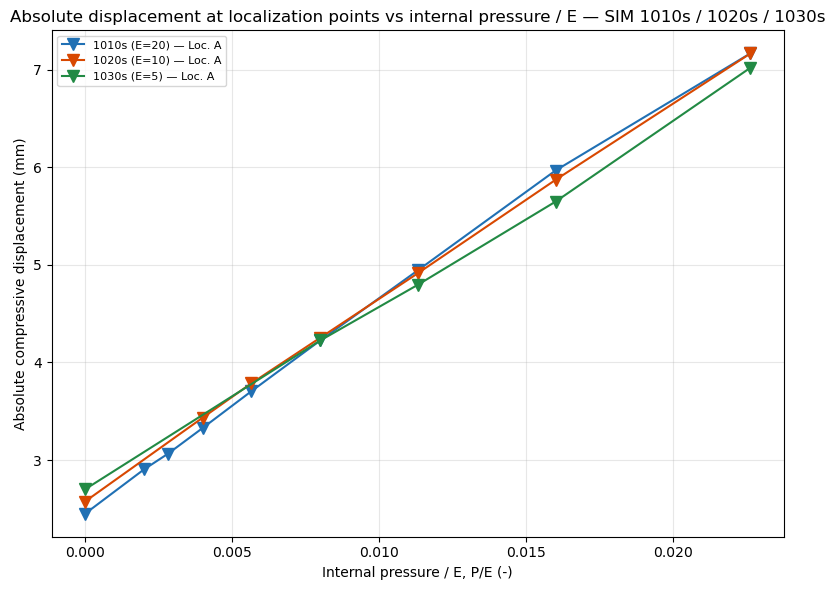

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

for fam, info in FAMILIES.items():
    base_color = plt.get_cmap(info['cmap'])(0.75)
    E = info['E']
    dA = [d for d in loc_data if d['fam'] == fam and not np.isnan(d['dispA_abs'])]
    dB = [d for d in loc_data if d['fam'] == fam and not np.isnan(d['dispB_abs'])]

    if dA:
        ax.plot([d['P'] / E for d in dA], [d['dispA_abs'] for d in dA], marker='v', ms=8,
                color=base_color, label=f"{fam} (E={info['E']}) — Loc. A")
    if dB:
        ax.plot([d['P'] / E for d in dB], [d['dispB_abs'] for d in dB], marker='^', ms=8,
                linestyle='--', color=base_color, label=f"{fam} (E={info['E']}) — Loc. B")

ax.set_xlabel('Internal pressure / E, P/E (-)')
ax.set_ylabel('Absolute compressive displacement (mm)')
ax.set_title('Absolute displacement at localization points vs internal pressure / E — SIM 1010s / 1020s / 1030s')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


### Plot 5e — Factor f at localization point vs absolute compressive displacement — all families


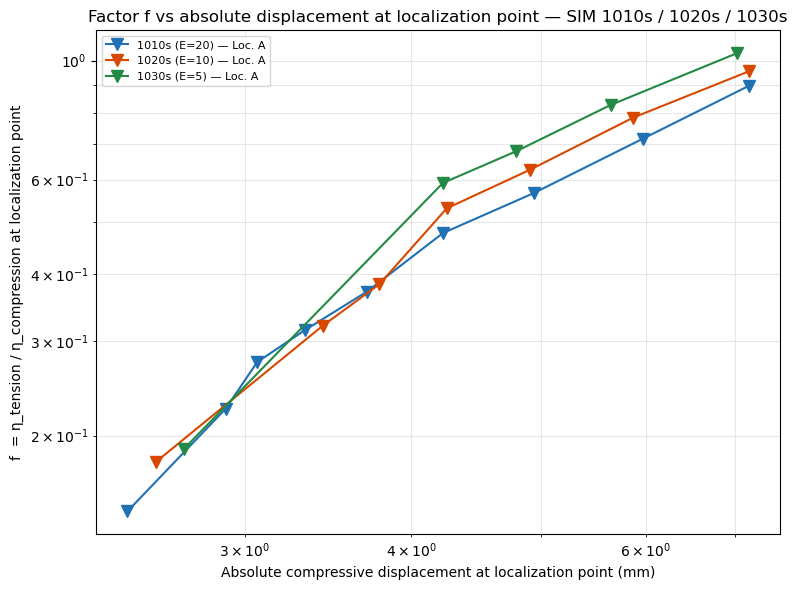

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

for fam, info in FAMILIES.items():
    base_color = plt.get_cmap(info['cmap'])(0.75)
    dA = [d for d in loc_data if d['fam'] == fam and not np.isnan(d['fA'])]
    dB = [d for d in loc_data if d['fam'] == fam and not np.isnan(d['fB'])]

    if dA:
        ax.plot([d['dispA_abs'] for d in dA], [d['fA'] for d in dA], marker='v', ms=8,
                color=base_color, label=f"{fam} (E={info['E']}) — Loc. A")
    if dB:
        ax.plot([d['dispB_abs'] for d in dB], [d['fB'] for d in dB], marker='^', ms=8,
                linestyle='--', color=base_color, label=f"{fam} (E={info['E']}) — Loc. B")

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Absolute compressive displacement at localization point (mm)')
ax.set_ylabel('f  = η_tension / η_compression at localization point')
ax.set_title('Factor f vs absolute displacement at localization point — SIM 1010s / 1020s / 1030s')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')
fig.tight_layout()
plt.show()
